# Analysis of World Happiness Data using Python

# 1. Motivation
The World Happiness Report is the resultof a survey of the state of global happiness. The United Nation’s Sustainable Development Solutions Network publishes the world happiness report annually.  The report ranks countries on how happy their citizens perceive themselves to be based on various indicators.The report continues to gain global recognition as governments, organizations and civil society increasingly use happiness indicators to inform their policymaking decisions. Using world happiness report 2021, this project aims to analyze (1) factors that impact happiness score other variables (such as life expectancy, GDP per capita, corruption, freedom to make life choices) or vice versa, (2) the global distribution of happiness score.The findings can be used as an input for policymakers.  

# 2. Import libraries
Let us begin by importing the libraries to be used in the analyis. They include numpy, pandas for dataframe, dataseries, matplotlib and seaborn for visualization.

In [189]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

# 3. Data reading, preparation and cleaning
This section reads, prepars and cleans the data to be used and presents. The data is obtained from Kaggle website and is given as world-happiness-report-2021.csv.

In [190]:
# let's read the world happiness report data for the year 2021

happiness_data = pd.read_csv('world-happiness-report-2021.csv')
data.shape

(149, 9)

In [18]:
happiness_data.head()

,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.0,0.949,-0.098,0.186,2.43,1.446,1.106,0.741,0.691,0.124,0.481,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.7,0.946,0.030,0.179,2.43,1.502,1.108,0.763,0.686,0.208,0.485,2.868
2,Switzerland,Western Europe,7.571,0.036,7.643,7.500,11.117,0.942,74.4,0.919,0.025,0.292,2.43,1.566,1.079,0.816,0.653,0.204,0.413,2.839
3,Iceland,Western Europe,7.554,0.059,7.670,7.438,10.878,0.983,73.0,0.955,0.160,0.673,2.43,1.482,1.172,0.772,0.698,0.293,0.170,2.967
4,Netherlands,Western Europe,7.464,0.027,7.518,7.410,10.932,0.942,72.4,0.913,0.175,0.338,2.43,1.501,1.079,0.753,0.647,0.302,0.384,2.798


In [19]:
# checking null values
happiness_data.isnull().sum()

Country name                                  0
Regional indicator                            0
Ladder score                                  0
Standard error of ladder score                0
upperwhisker                                  0
lowerwhisker                                  0
Logged GDP per capita                         0
Social support                                0
Healthy life expectancy                       0
Freedom to make life choices                  0
Generosity                                    0
Perceptions of corruption                     0
Ladder score in Dystopia                      0
Explained by: Log GDP per capita              0
Explained by: Social support                  0
Explained by: Healthy life expectancy         0
Explained by: Freedom to make life choices    0
Explained by: Generosity                      0
Explained by: Perceptions of corruption       0
Dystopia + residual                           0
dtype: int64

We see that the data contains no missing values. 

In [20]:
happiness_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 20 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country name                                149 non-null    object 
 1   Regional indicator                          149 non-null    object 
 2   Ladder score                                149 non-null    float64
 3   Standard error of ladder score              149 non-null    float64
 4   upperwhisker                                149 non-null    float64
 5   lowerwhisker                                149 non-null    float64
 6   Logged GDP per capita                       149 non-null    float64
 7   Social support                              149 non-null    float64
 8   Healthy life expectancy                     149 non-null    float64
 9   Freedom to make life choices                149 non-null    float64
 10  Generosity    

The data contains 149 raws (countries) and 20 total columns (variables) with data types (float = 18, object = 2).

In [21]:
happiness_data.head(2)

,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.0,0.949,-0.098,0.186,2.43,1.446,1.106,0.741,0.691,0.124,0.481,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.7,0.946,0.030,0.179,2.43,1.502,1.108,0.763,0.686,0.208,0.485,2.868


#### Extracting columns (variables)
All the variables in the data are not required for the analysis. Variable of interst to the analysis are selected.

In [24]:
# Extracting the columns (variables) that are of interest to the analysis.
happiness_data_columns = ['Country name', 'Regional indicator', 'Ladder score', 'Logged GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

In [34]:
# Coppy the selected columns
happiness_data = happiness_data[happiness_data_columns].copy()

In [35]:
happiness_data.head()

,Country name,Regional indicator,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,Finland,Western Europe,7.842,10.775,0.954,72.0,0.949,-0.098,0.186
1,Denmark,Western Europe,7.620,10.933,0.954,72.7,0.946,0.030,0.179
2,Switzerland,Western Europe,7.571,11.117,0.942,74.4,0.919,0.025,0.292
3,Iceland,Western Europe,7.554,10.878,0.983,73.0,0.955,0.160,0.673
4,Netherlands,Western Europe,7.464,10.932,0.942,72.4,0.913,0.175,0.338


This is the final data to be used in the analysis. 

In [142]:
happiness_data.columns

Index(['Country name', 'Regional indicator', 'Happiness_score',
       'Logged GDP per capita', 'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='object')

In [144]:
# Renaming of the variable in the data for easy use and understanding
happiness_data.rename(columns={'Country name':'Country_name','Regional indicator':'Regional_indicator',
                               'Ladder score':'Happiness_score', 'Logged GDP per capita':'Logged_GDP_per_capita',
                              'Social support':'Social_support', 'Healthy life expectancy':'Healthy_life_expectancy',
                              'Freedom to make life choices':'Freedom_to_make_life_choices',
                              'Generosity':'Generosity','Perceptions of corruption':'Perceptions_of_corruption'}, inplace=True)
happiness_data.head()

,Country_name,Regional_indicator,Happiness_score,Logged_GDP_per_capita,Social_support,Healthy_life_expectancy,Freedom_to_make_life_choices,Generosity,Perceptions_of_corruption
0,Finland,Western Europe,7.842,10.775,0.954,72.0,0.949,-0.098,0.186
1,Denmark,Western Europe,7.620,10.933,0.954,72.7,0.946,0.030,0.179
2,Switzerland,Western Europe,7.571,11.117,0.942,74.4,0.919,0.025,0.292
3,Iceland,Western Europe,7.554,10.878,0.983,73.0,0.955,0.160,0.673
4,Netherlands,Western Europe,7.464,10.932,0.942,72.4,0.913,0.175,0.338


# 4. Data visualization
So far, I have been preparing the data for analysis. This section presents the analysis of the variables of interst using various visualization techniques. 

### Correlation between variables in the data
In this section, I present the relationship of each of the variables in the data using Pearson correlation coefficient.

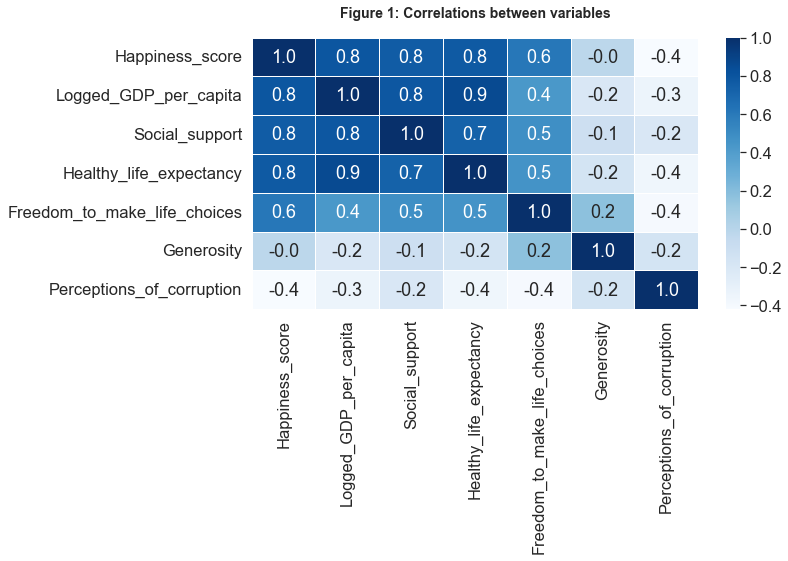

In [186]:
# Heatmap correlation matrix

f,ax = plt.subplots(figsize=(10, 5))
sns.heatmap(happiness_data.corr(), annot=True, linewidths=.5, cmap='Blues', fmt= '.1f',ax=ax)

plt.title('Figure 1: Correlations between variables', fontsize=14, fontweight='bold', pad=20);

plt.show()

Accprding to figure 1, three variables (the GDP per capita, social support and healthy life expectancy appear to have strong positive  correlation with the happiness score (with a correlation coefficient of 0.8) followed by freedom to make life choices (0.6). Perception of corruption and happiness score are negatively correlated (-0.4) suggesting that happiness decreases with increase in corruption. The strongest correlation in our correlation matrix is is seen between GDP per capit (log) and healthy life expectancy indicating that countries with higher GDP per capita enjoy higher healthy life expectancy.

In [152]:
sns.set_style('whitegrid')

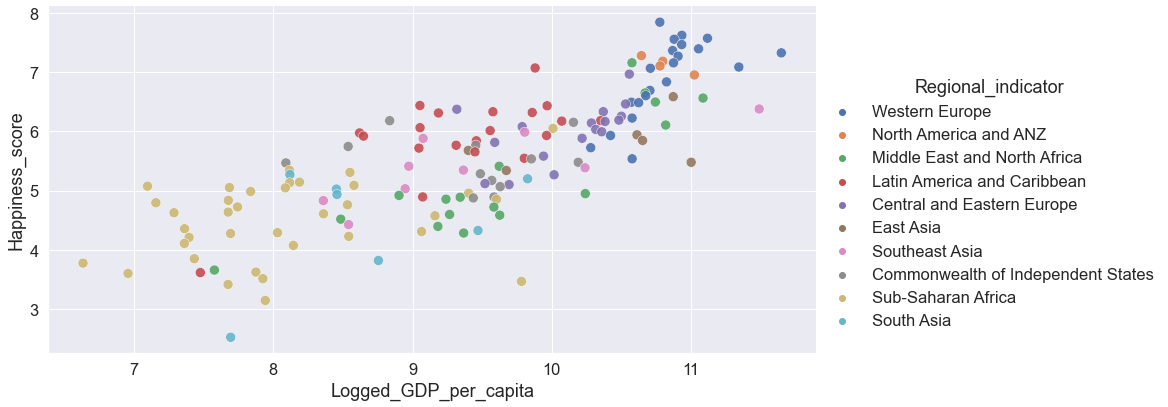

In [160]:
# Scattor plot of GDP per capita and happiness score (ladder score)

sns.set(font_scale=1.5)
sns.relplot(data=happiness_data, x='Logged_GDP_per_capita', y='Happiness_score', hue='Regional_indicator', s= 100, alpha =0.9, edgecolors='grey', linewidth=0.5,sizes=(15, 200), height=6, aspect=2);

# plot.set_title('Relationship between GDP perr capita and happiness score')
# plot.set_axis_labels('GDP Per Capita', 'Happiness score')


plt.show()


A scatter plot showing the relationship between happiness score which ranges from 0 to 1 and GDP per capita for all the 149 countries grouped by the respective regions is provided in Figure 2. As indicated by the scatter plot, countries from Western Europe (blue color) - with variation among them - appear to have the highest hapinness score and GDP per capitafollowed by North American countries. Countries with the lowest happiness score and GDP per capita are found in the Subsaharan African region.The correlation coefficient between happiness score and GDP per capita is 0.79 suggesting that they are strongly related. 

In [182]:
# Correlation coefficient between happiness score and GDP per capita
np.corrcoef(happiness_data['Happiness_score'], happiness_data['Logged_GDP_per_capita'])

array([[1.       , 0.7897597],
       [0.7897597, 1.       ]])

In [162]:
# How many countries are there in each region?

num_countries = happiness_data.groupby('Regional_indicator')[['Country_name']].count()
num_countries

,Country_name
Regional_indicator,
Central and Eastern Europe,17
Commonwealth of Independent States,12
East Asia,6
Latin America and Caribbean,20
Middle East and North Africa,17
North America and ANZ,4
South Asia,7
Southeast Asia,9
Sub-Saharan Africa,36


In [161]:
#Average happiness score by region

happiness_data.groupby('Regional_indicator').Happiness_score.mean()

Regional_indicator
Central and Eastern Europe            5.984765
Commonwealth of Independent States    5.467000
East Asia                             5.810333
Latin America and Caribbean           5.908050
Middle East and North Africa          5.219765
North America and ANZ                 7.128500
South Asia                            4.441857
Southeast Asia                        5.407556
Sub-Saharan Africa                    4.494472
Western Europe                        6.914905
Name: Happiness_score, dtype: float64

<AxesSubplot:xlabel='Happiness_score', ylabel='Regional_indicator'>

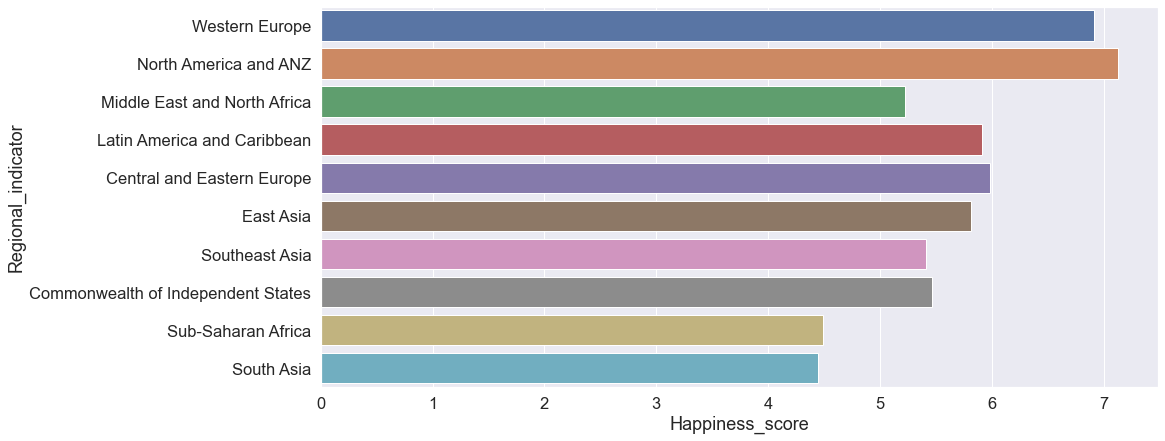

In [177]:
#Plot average happiness score by region
#sns.set_title('Figure 3:Average happiness score by region')
#plt.figure(figsize(15,5))
sns.barplot(x = 'Happiness_score', y = 'Regional_indicator', ci=None, data = happiness_data)

From this figure, we can clearly see that North America region enjoy happier life followed by Western Europe. However, this does not mean that individual countries are at the top of the ladder. As a region South Asis seems to the least happiest region followed by Sub-Saharan Africa. 

### Correlation between happiness score and healthy life expectancy

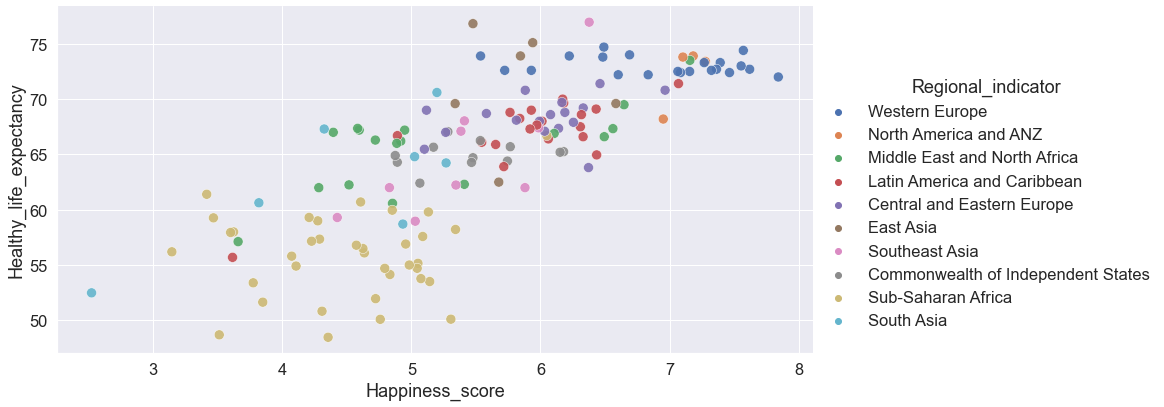

In [178]:
sns.set(font_scale=1.5)
sns.relplot(data=happiness_data, x='Happiness_score', y='Healthy_life_expectancy', hue='Regional_indicator', s= 100, alpha =0.9, edgecolors='grey', linewidth=0.5,sizes=(15, 200), height=6, aspect=2);


In [181]:
# Correlation coefficient between happiness score and healthy life expectancy
np.corrcoef(happiness_data['Happiness_score'], happiness_data['Healthy_life_expectancy'])

array([[1.        , 0.76809946],
       [0.76809946, 1.        ]])

In terms of correlation coefficient, happiness score and life expectancy are strongly correlated (0.77).